In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf

2025-10-15 22:02:38.399605: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import pandas as pd

df = pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
value_counts = df['Exited'].value_counts()
value_counts

Exited
0    7963
1    2037
Name: count, dtype: int64

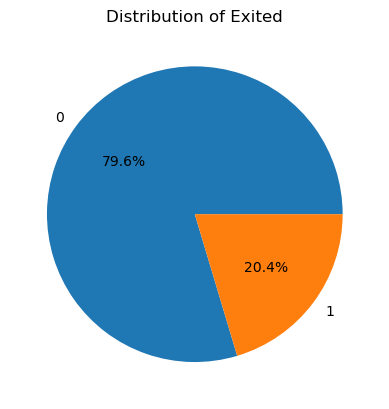

In [5]:
import matplotlib.pyplot as plt

labels = value_counts.index
counts = value_counts.values
plt.pie(counts,labels=labels,autopct='%1.1f%%')
plt.title('Distribution of Exited')
plt.show()

In [6]:
from imblearn.over_sampling import RandomOverSampler

input_columns = df.drop('Exited',axis=1)
class_column = df['Exited']
oversampler = RandomOverSampler(random_state=0)
input_columns_resampled,class_column_resampled = oversampler.fit_resample(input_columns,class_column)

df_balanced = pd.concat([input_columns_resampled,class_column_resampled ],axis=1)
class_disribution = df_balanced['Exited'].value_counts()
class_disribution

Exited
1    7963
0    7963
Name: count, dtype: int64

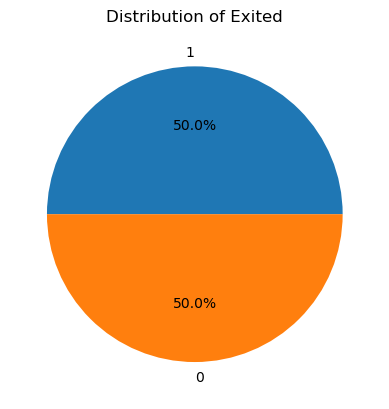

In [7]:
value_counts = df_balanced['Exited'].value_counts()
labels = value_counts.index
counts = value_counts.values
plt.pie(counts,labels=labels,autopct='%1.1f%%')
plt.title('Distribution of Exited')
plt.show()

In [8]:
X = df_balanced.iloc[:,3:13].values
X

array([[619, 'France', 'Female', ..., 1, 1, 101348.88],
       [608, 'Spain', 'Female', ..., 0, 1, 112542.58],
       [502, 'France', 'Female', ..., 1, 0, 113931.57],
       ...,
       [565, 'Germany', 'Male', ..., 1, 0, 175070.94],
       [553, 'Spain', 'Female', ..., 0, 1, 30730.95],
       [492, 'France', 'Female', ..., 1, 1, 182865.09]], dtype=object)

In [9]:
Y = df_balanced.iloc[:,13].values
Y

array([1, 0, 1, ..., 1, 1, 1])

In [10]:
from sklearn.preprocessing import LabelEncoder

labelencoder_gender = LabelEncoder()
X[:,2] = labelencoder_gender.fit_transform(X[:,2])
X[:,2] 

array([0, 0, 0, ..., 1, 0, 0], dtype=object)

In [11]:
import numpy as np 

distinct_values = np.unique(X[:,1])
distinct_values

array(['France', 'Germany', 'Spain'], dtype=object)

In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[1])],remainder='passthrough')
X = ct.fit_transform(X)

In [13]:
X[0]

array([1.0, 0.0, 0.0, 619, 0, 42, 2, 0.0, 1, 1, 1, 101348.88],
      dtype=object)

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=0)


In [15]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [16]:
X_train

array([[-0.93041226, -0.6660016 ,  1.83627033, ..., -1.55261795,
        -0.92478892, -0.87888847],
       [ 1.07479237, -0.6660016 , -0.54458213, ...,  0.64407345,
        -0.92478892, -1.26171023],
       [-0.93041226, -0.6660016 ,  1.83627033, ...,  0.64407345,
         1.08132784,  1.70394276],
       ...,
       [-0.93041226, -0.6660016 ,  1.83627033, ...,  0.64407345,
         1.08132784,  0.83065375],
       [-0.93041226,  1.50149789, -0.54458213, ...,  0.64407345,
        -0.92478892, -1.2493363 ],
       [-0.93041226,  1.50149789, -0.54458213, ...,  0.64407345,
        -0.92478892,  0.31223535]])

In [17]:
import numpy as np 
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)


In [18]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()


In [19]:
input_dim = len(X_train[0])

model.add(Dense(6,activation='relu',input_dim=input_dim))
model.add(Dense(6,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/home/abdulrahman/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-15 22:02:42.238787: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-10-15 22:02:42.238843: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2025-10-15 22:02:42.238886: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-10-15 22:02:42.238896: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun wit

In [20]:
model.compile(optimizer = 'adam',loss='binary_crossentropy',metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127 (508.00 B)

 Trainable params: 127 (508.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.fit(X_train,Y_train,batch_size=10,epochs=10)


Epoch 1/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6335 - loss: 0.6413
Epoch 2/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7513 - loss: 0.5213
Epoch 3/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7673 - loss: 0.4842
Epoch 4/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7713 - loss: 0.4741
Epoch 5/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7731 - loss: 0.4695
Epoch 6/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7729 - loss: 0.4667
Epoch 7/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7732 - loss: 0.4646
Epoch 8/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7756 - loss: 0.4628
Epoch 9/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7750 - loss: 0.4612
Epoch 10/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7758 - loss: 0.4598


In [23]:
evaluate = model.evaluate(X_test,Y_test)
print('loss ',evaluate[0])
print('aaccuracy ',evaluate[1])

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7725 - loss: 0.4749   
loss  0.4748808741569519
aaccuracy  0.7724761366844177


In [24]:
y_pred = model.predict(X_test)
y_pred_binary = (y_pred>0.5)
y_pred_binary

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step


array([[False],
       [ True],
       [ True],
       ...,
       [ True],
       [False],
       [ True]])

In [25]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

accuracy = accuracy_score(Y_test,y_pred_binary)
print('accuracy ', accuracy)

precision = precision_score(Y_test,y_pred_binary)
print('precision ', precision)

recall = recall_score(Y_test,y_pred_binary)
print('recall ', recall)

f1 = f1_score(Y_test,y_pred_binary)
print('f1 ', f1)

accuracy  0.7724761426418885
precision  0.7755410166079517
recall  0.7701149425287356
f1  0.7728184553660983


In [26]:
model = Sequential()
input_dim = len(X_train[0])

model.add(Dense(128,activation='relu',input_dim=input_dim))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer = 'adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(X_train,Y_train,batch_size=10,epochs=20)

Epoch 1/20


/home/abdulrahman/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1195/1195 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7470 - loss: 0.5055
Epoch 2/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7838 - loss: 0.4466
Epoch 3/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7943 - loss: 0.4293
Epoch 4/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8016 - loss: 0.4149
Epoch 5/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8089 - loss: 0.4009
Epoch 6/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8187 - loss: 0.3874
Epoch 7/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8254 - loss: 0.3745
Epoch 8/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8341 - loss: 0.3617
Epoch 9/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8409 - loss: 0.3475
Epoch 10/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8506 - loss: 0.3365
Epoch 11/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8516 - loss: 0.3253
Epoch 12/20
1195/1195 ━━━━━━━━━━━━━━━━━━━

In [27]:
y_pred = model.predict(X_test)
y_pred_binary = (y_pred>0.5)
y_pred_binary
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

accuracy = accuracy_score(Y_test,y_pred_binary)
print('accuracy ', accuracy)

precision = precision_score(Y_test,y_pred_binary)
print('precision ', precision)

recall = recall_score(Y_test,y_pred_binary)
print('recall ', recall)

f1 = f1_score(Y_test,y_pred_binary)
print('f1 ', f1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
accuracy  0.8395278754394776
precision  0.8255258126195029
recall  0.8630684657671165
f1  0.8438797947715612


In [28]:
model.save('churn_model.keras')

In [29]:
from joblib import dump

dump(labelencoder_gender,'churn_label_encoder.pkl')

['churn_label_encoder.pkl']

In [30]:
from joblib import dump

dump(ct,'churn_column_transformer.pkl')

['churn_column_transformer.pkl']

In [31]:
from joblib import dump

dump(sc,'churn_standard_scalar.pkl')

['churn_standard_scalar.pkl']

In [32]:
new_customer = np.array([[600,'France','Male',40,30,60000,2,1,1,50000]])

In [33]:
from joblib import load

labelencoder_gender_loaded=load('churn_label_encoder.pkl')
new_customer[:,2] = labelencoder_gender_loaded.transform(new_customer[:,2])

In [34]:
ct_loaded = load('churn_column_transformer.pkl')
new_customer= ct.transform(new_customer)

In [35]:
sc_loaded = load('churn_standard_scalar.pkl')
new_customer= sc.transform(new_customer)

In [36]:
new_customer

array([[ 1.07351406, -0.66107968, -0.54852718, -0.49377205,  0.97568478,
        -0.11551331,  8.54606174, -0.36336378,  0.7051668 ,  0.67287032,
         1.08496359, -0.8898102 ]])

In [37]:
from keras.models import load_model
loaded_model = load_model('churn_model.keras')

In [38]:
new_prediction_propa = loaded_model.predict(new_customer)
new_prediction = (new_prediction_propa > 0.5)
new_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


array([[False]])